<a href="https://www.kaggle.com/code/riteshkumarweb/handle-imbalanceda-dataset?scriptVersionId=323741693" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# 📊 Imbalanced Dataset

# An Imbalanced Dataset is a dataset where
# one class has significantly more samples
# than another class

# Example:

# Class 0 → 950 samples ✅
# Class 1 → 50 samples ❌

# Here:
# Majority Class → Class 0
# Minority Class → Class 1

# 🎯 Problem:

# Model may learn only majority class

# Example:
# Predict everything as Class 0

# Accuracy = 95%

# Looks good 😲

# But model completely fails
# to detect Class 1

# Therefore Accuracy becomes misleading

# We use:
# Precision
# Recall
# F1-Score
# ROC-AUC

# instead of only Accuracy


# 🤔 Why do we study Imbalanced Datasets?

# Real-world datasets are often imbalanced

# Examples:

# Fraud Detection 💳
# Fraud → 1%
# Normal → 99%

# Disease Prediction 🏥
# Disease → Rare
# Healthy → Common

# Spam Detection 📧
# Spam → Few
# Normal Emails → Many

# Therefore we need techniques
# to properly learn minority class


# =====================================================
# 📦 1. Undersampling
# =====================================================

# 🎯 Reduce majority class samples

# Example:

# Before:
# Class 0 → 1000
# Class 1 → 100

# After:
# Class 0 → 100
# Class 1 → 100

# ✅ Faster training
# ❌ Loses information

# Example:

# from imblearn.under_sampling import RandomUnderSampler
# rus = RandomUnderSampler(random_state=42)
# X_resampled, y_resampled = rus.fit_resample(X, y)


# =====================================================
# 📦 2. Oversampling
# =====================================================

# 🎯 Increase minority class samples

# Example:

# Before:
# Class 0 → 1000
# Class 1 → 100

# After:
# Class 0 → 1000
# Class 1 → 1000

# Done by duplicating minority samples

# ✅ No information loss
# ❌ May cause overfitting

# Example:

# from imblearn.over_sampling import RandomOverSampler
# ros = RandomOverSampler(random_state=42)
# X_resampled, y_resampled = ros.fit_resample(X, y)


# =====================================================
# 📦 3. SMOTE
# =====================================================

# SMOTE =
# Synthetic Minority Oversampling Technique

# 🎯 Create NEW synthetic samples
# instead of duplicating existing ones

# Example:

# Minority Samples:

# A ●--------● B

# SMOTE creates:
# ● between A and B

# ✅ Better than simple oversampling
# ✅ Reduces overfitting

# Example:

# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X, y)


# =====================================================
# 📦 4. Ensemble Methods
# =====================================================

# 🎯 Use multiple models together

# Examples:

# Balanced Random Forest 🌲
# EasyEnsemble ⚡

# Idea:
# Multiple models focus on minority class

# ✅ Better performance
# ✅ More robust

# Example:

# from imblearn.ensemble import BalancedRandomForestClassifier

# model = BalancedRandomForestClassifier(
#     random_state=42
# )


# =====================================================
# 📦 5. Cost-Sensitive Learning
# =====================================================

# 🎯 Assign higher penalty
# for misclassifying minority class

# Example:

# Predict Healthy instead of Disease
# → Very costly ❌

# Therefore:
# Give minority class more importance

# Commonly done using:

# class_weight='balanced'

# Example:

# LogisticRegression(
#     class_weight='balanced'
# )

# DecisionTreeClassifier(
#     class_weight='balanced'
# )

# RandomForestClassifier(
#     class_weight='balanced'
# )


# 📊 Summary

# Undersampling
# → Remove majority samples

# Oversampling
# → Duplicate minority samples

# SMOTE
# → Create synthetic minority samples

# Ensemble Methods
# → Multiple models focus on minority class

# Cost-Sensitive Learning
# → Increase penalty for minority class mistakes

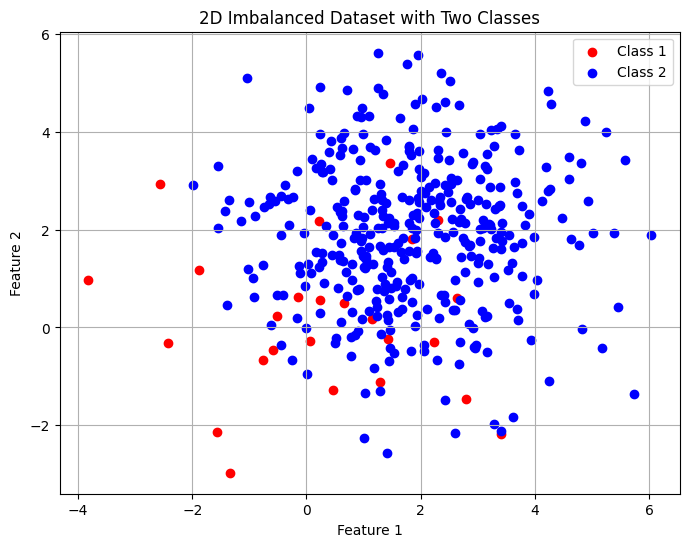

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Set random seed for reproducibility
np.random.seed(42)

# Generate imbalanced dataset
n_samples_1 = 25 # Number of samples in class 1
n_samples_2 = 375 # Number of samples in class 2
centers = [(0, 0), (2, 2)] # Centers of each cluster
cluster_std = [1.5, 1.5] # Standard deviation of each cluster

X, y = make_blobs(n_samples=[n_samples_1, n_samples_2],
centers=centers,
cluster_std=cluster_std,
random_state=0)

# Plotting
plt.figure(figsize=(8,6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 1')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)

# Random Undersampling

In [35]:
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# UnderSampling
rus = RandomUnderSampler(random_state=42)

X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

# Train Model
model = LogisticRegression()

model.fit(X_resampled, y_resampled)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nBefore Resampling")
print(pd.Series(y_train).value_counts())
print("\nAfter Resampling")
print(pd.Series(y_resampled).value_counts())

              precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80

ROC AUC: 0.9375

Before Resampling
1    299
0     21
Name: count, dtype: int64

After Resampling
0    21
1    21
Name: count, dtype: int64


Classification Report (With Over Sampling):
              precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80

ROC AUC Score (With Over Sampling): 0.9375


# Random Oversampling 

In [36]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# OverSampling
ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

# Train Model
model = LogisticRegression()

model.fit(X_resampled, y_resampled)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nBefore Resampling")
print(pd.Series(y_train).value_counts())
print("\nAfter Resampling")
print(pd.Series(y_resampled).value_counts())

              precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80

ROC AUC: 0.950657894736842

Before Resampling
1    299
0     21
Name: count, dtype: int64

After Resampling
1    299
0    299
Name: count, dtype: int64


# SMOTE

In [37]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample( X_train,y_train)

# Train Model
model = LogisticRegression()

model.fit(X_resampled, y_resampled)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nBefore Resampling")
print(pd.Series(y_train).value_counts())
print("\nAfter Resampling")
print(pd.Series(y_resampled).value_counts())

              precision    recall  f1-score   support

           0       0.17      1.00      0.30         4
           1       1.00      0.75      0.86        76

    accuracy                           0.76        80
   macro avg       0.59      0.88      0.58        80
weighted avg       0.96      0.76      0.83        80

ROC AUC: 0.950657894736842

Before Resampling
1    299
0     21
Name: count, dtype: int64

After Resampling
1    299
0    299
Name: count, dtype: int64


# Ensemble Method (Balanced Random Forest)

In [38]:
from sklearn.model_selection import train_test_split
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)
# Balanced Random Forest
model = BalancedRandomForestClassifier(random_state=42)

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.13      0.50      0.21         4
           1       0.97      0.83      0.89        76

    accuracy                           0.81        80
   macro avg       0.55      0.66      0.55        80
weighted avg       0.93      0.81      0.86        80

ROC AUC: 0.8273026315789473

Before Resampling
1    299
0     21
Name: count, dtype: int64

After Resampling
1    299
0    299
Name: count, dtype: int64


# Cost Sensitive Learning

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Cost Sensitive Logistic Regression
model = LogisticRegression(class_weight='balanced')

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.19      1.00      0.32         4
           1       1.00      0.78      0.87        76

    accuracy                           0.79        80
   macro avg       0.60      0.89      0.60        80
weighted avg       0.96      0.79      0.85        80

ROC AUC: 0.9473684210526316


# And Many more Method find out in this 
https://imbalanced-learn.org/stable/references/